# Save result pic as videos

In [1]:
import os
import cv2
from tqdm import tqdm

# folders
camera_pic_folders = ['finalstep_3', 'finalrandla_3','finalmean_3', 'finalcombine_3']
output_folder = 'videos'  # where the .mp4 files will be written
os.makedirs(output_folder, exist_ok=True)

# parameters
fps = 16  # frames per second for the output video
# try 'mp4v' first; if your player can't open the result, try 'avc1' (H.264) or switch to .avi with 'XVID'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

def numeric_key(fn):
    """Sort by the numeric filename (without extension); fall back to lexicographic."""
    name, _ = os.path.splitext(fn)
    try:
        return int(name)
    except ValueError:
        return name  # fallback for non-numeric

for current_folder in tqdm(camera_pic_folders, desc="Building videos", unit="folder"):
    if not os.path.isdir(current_folder):
        print(f"Skip: '{current_folder}' is not a directory.")
        continue

    # each subfolder in current_folder becomes one video
    list_subfolders = [d for d in os.listdir(current_folder)
                       if os.path.isdir(os.path.join(current_folder, d))]
    if not list_subfolders:
        print(f"No subfolders found in '{current_folder}'.")
        continue

    for sub in tqdm(list_subfolders, desc=f"Building {current_folder}", unit="subfolder"):
        cam_dir = os.path.join(current_folder, sub)
        files = sorted(
            [f for f in os.listdir(cam_dir) if f.lower().endswith('.png')],
            key=numeric_key
        )

        if not files:
            print(f"No .png files in '{cam_dir}'. Skipping.")
            continue

        # determine frame size (W, H) correctly
        first_path = os.path.join(cam_dir, files[0])
        first_img = cv2.imread(first_path, cv2.IMREAD_COLOR)
        if first_img is None:
            print(f"Cannot read first image: {first_path}. Skipping.")
            continue
        H, W = first_img.shape[:2]  # shape returns (H, W, C)
        frame_size = (W, H)         # VideoWriter expects (width, height)

        # create output path mirroring current_folder structure
        out_dir = os.path.join(output_folder, current_folder)
        os.makedirs(out_dir, exist_ok=True)
        out_path = os.path.join(out_dir, f'{sub}.mp4')

        writer = cv2.VideoWriter(out_path, fourcc, fps, frame_size)
        if not writer.isOpened():
            print(f"Failed to open writer for: {out_path}")
            continue

        # write frames
        wrote = 0
        for fn in (files):
            img_path = os.path.join(cam_dir, fn)
            frame = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if frame is None:
                print(f"Warning: couldn't read {img_path}; skipping.")
                continue
            if frame.shape[1] != W or frame.shape[0] != H:
                # resize mismatched frames to the target size
                frame = cv2.resize(frame, frame_size, interpolation=cv2.INTER_AREA)
            writer.write(frame)
            wrote += 1

        writer.release()

        # if wrote == 0:
        #     print(f"No frames written for {out_path}. The video will be empty.")
        #     # optional: os.remove(out_path)
        # else:
        #     print(f"✅ Wrote {wrote} frames to {out_path}")


Building videos: 100%|██████████| 4/4 [18:42<00:00, 280.72s/folder]


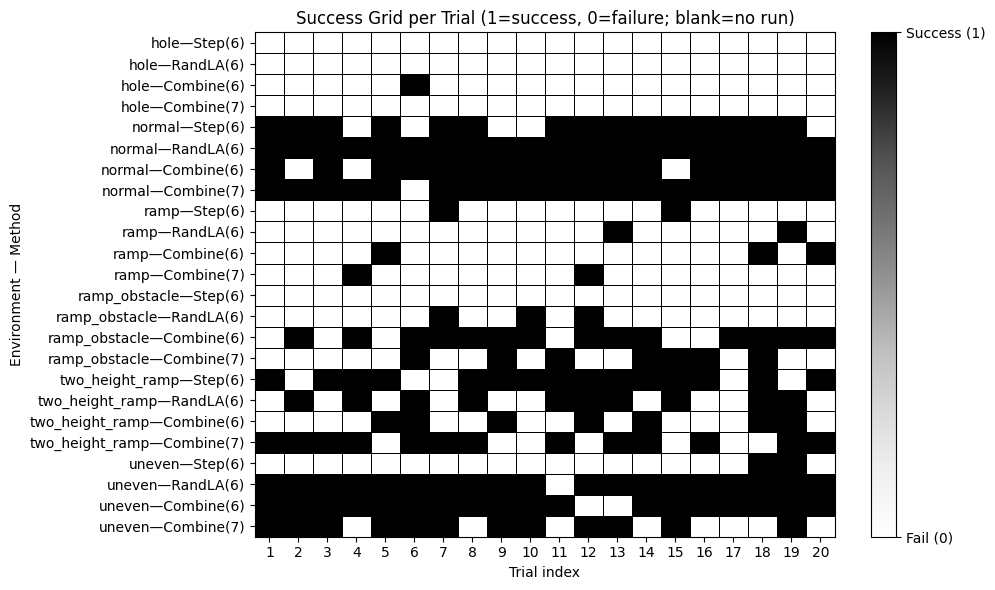

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import json
from collections import defaultdict
with open('step_stats_6.json') as f:
    data = json.load(f)
with open('randla_stats_6.json') as f2:
    data2 = json.load(f2)

with open('combine_stats_6.json') as f3:
    data3 = json.load(f3)

with open('test_stats_8.json') as f4:
    data4 = json.load(f4)
# Map env names
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def env_label_for(entry):
    start = tuple(round(x) for x in entry["start_point"])
    goal  = tuple(round(x) for x in entry["goal_point"])
    return env_map.get((start, goal), f"{start}→{goal}")

# Build {env: [0/1 ...]} for each method
def success_vectors(raw_entries):
    by_env = defaultdict(list)
    for e in raw_entries:
        lbl = env_label_for(e)
        by_env[lbl].append(1 if e.get("reach_goal") else 0)
    return by_env

step6   = success_vectors(data)
randla6 = success_vectors(data2)
comb6   = success_vectors(data3)
comb7   = success_vectors(data4)

# Unified set of environments, sorted for stable row order
all_envs = sorted(set(step6) | set(randla6) | set(comb6) | set(comb7))

# Row labels in your requested style per environment
methods = [
    ("Step(6)",   step6),
    ("RandLA(6)", randla6),
    ("Combine(6)",comb6),
    ("Combine(7)",comb7),
]

row_labels = []
rows = []

for env in all_envs:
    for mname, mdict in methods:
        row_labels.append(f"{env}—{mname}")
        rows.append(mdict.get(env, []))

# Determine width (max trials across all rows) and build a padded matrix
max_len = max((len(r) for r in rows), default=0)
grid = np.full((len(rows), max_len), np.nan)  # NaN will render as blank

for i, r in enumerate(rows):
    if len(r) > 0:
        grid[i, :len(r)] = r  # fill with 0/1

# --- Plot as a crisp grid ---
fig, ax = plt.subplots(figsize=(max(10, max_len*0.35), max(6, len(rows)*0.25)))

# Use pcolormesh so we can draw cell borders easily
# Values: 1 (success), 0 (fail), NaN (no run)
c = ax.pcolormesh(
    np.arange(max_len+1), np.arange(len(rows)+1),
    np.flipud(grid),  # flip vertically to have first row at top
    shading='flat', edgecolors='black', linewidth=0.4,
    cmap='Greys', vmin=0, vmax=1
)

# Ticks: trials on x, row labels on y
ax.set_xticks(np.arange(max_len) + 0.5)
ax.set_xticklabels([str(i+1) for i in range(max_len)], rotation=0)
ax.set_xlabel("Trial index")

ax.set_yticks(np.arange(len(rows)) + 0.5)
ax.set_yticklabels(list(reversed(row_labels)))  # because we flipped grid
ax.set_ylabel("Environment — Method")

ax.set_title("Success Grid per Trial (1=success, 0=failure; blank=no run)")
cb = fig.colorbar(c, ax=ax, ticks=[0, 1])
cb.ax.set_yticklabels(['Fail (0)', 'Success (1)'])

plt.tight_layout()
plt.show()


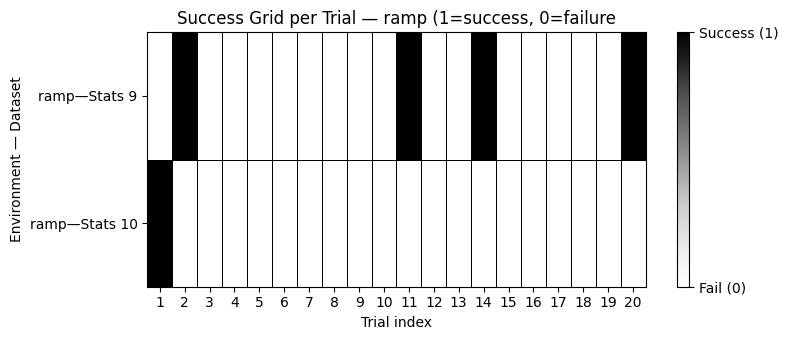

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import json
from collections import defaultdict

# --- Load the two stats files ---
with open('test_stats_9.json') as f1:
    data_a = json.load(f1)

with open('test_stats_10.json') as f2:
    data_b = json.load(f2)

# Map env names
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def env_label_for(entry):
    start = tuple(round(x) for x in entry["start_point"])
    goal  = tuple(round(x) for x in entry["goal_point"])
    return env_map.get((start, goal), f"{start}→{goal}")

# Build {env: [0/1 ...]} for each dataset
def success_vectors(raw_entries):
    by_env = defaultdict(list)
    for e in raw_entries:
        lbl = env_label_for(e)
        by_env[lbl].append(1 if e.get("reach_goal") else 0)
    return by_env

# Compute success vectors for the two files
v9  = success_vectors(data_a)
v10 = success_vectors(data_b)

# We only want the "ramp" environment (be permissive in case of casing/variants)
target_envs = [e for e in set(v9) | set(v10) if e.lower() == "ramp"]

if not target_envs:
    # Fall back to any env label that contains 'ramp' (e.g., "two_height_ramp"), if strict 'ramp' is absent
    target_envs = [e for e in set(v9) | set(v10) if "ramp" in e.lower()]

if not target_envs:
    raise ValueError("No 'ramp' environment found in the provided files.")

# Prepare rows for plotting
methods = [
    ("Stats 9",  v9),
    ("Stats 10", v10),
]

row_labels = []
rows = []

for env in target_envs:  # typically just ["ramp"]
    for mname, mdict in methods:
        row_labels.append(f"{env}—{mname}")
        rows.append(mdict.get(env, []))

# Determine width (max trials across all rows) and build a padded matrix
max_len = max((len(r) for r in rows), default=0)
grid = np.full((len(rows), max_len), np.nan)  # NaN will render as blank

for i, r in enumerate(rows):
    if len(r) > 0:
        grid[i, :len(r)] = r  # fill with 0/1

# --- Plot as a crisp grid ---
fig, ax = plt.subplots(figsize=(max(8, max_len*0.35), max(3.5, len(rows)*0.5)))

# Values: 1 (success), 0 (fail), NaN (no run)
c = ax.pcolormesh(
    np.arange(max_len+1), np.arange(len(rows)+1),
    np.flipud(grid),  # flip vertically to have first row at top
    shading='flat', edgecolors='black', linewidth=0.4,
    cmap='Greys', vmin=0, vmax=1
)

# Ticks: trials on x, row labels on y
ax.set_xticks(np.arange(max_len) + 0.5)
ax.set_xticklabels([str(i+1) for i in range(max_len)], rotation=0)
ax.set_xlabel("Trial index")

ax.set_yticks(np.arange(len(rows)) + 0.5)
ax.set_yticklabels(list(reversed(row_labels)))  # because we flipped grid
ax.set_ylabel("Environment — Dataset")

title_env = ", ".join(target_envs)
ax.set_title(f"Success Grid per Trial — {title_env} (1=success, 0=failure")

cb = fig.colorbar(c, ax=ax, ticks=[0, 1])
cb.ax.set_yticklabels(['Fail (0)', 'Success (1)'])

plt.tight_layout()
plt.show()


# Combine Videos

In [ ]:
import os
import re
import cv2
import numpy as np
from tqdm import tqdm
from collections import defaultdict

# -------- CONFIG --------
VIDEOS_ROOT    = "videos"
GROUPS         = ['finalstep_3', 'finalrandla_3','finalmean_3', 'finalcombine_3']    # process both groups
OUT_SUBFMT     = "combine_{group}"      # per-group output subfolder
EXPECTED_COUNT = 20                      # we expect _1.._20

# Choose layout: "row" => 1xN, "2x3" => 2x3, "4x5" => 4x5
LAYOUT_MODE    = "4x5"                 # "row", "2x3", or "4x5"

# Reserve the last slot for an environment image (only if True)
RESERVE_LAST_FOR_IMAGE = False

# Visual tuning
TARGET_CELL_W  = 450
TARGET_CELL_H  = 288
GUTTER         = 6
BG_COLOR       = (0, 0, 0)              # BGR

# Labels
DRAW_LABELS    = True                   # turn labels on/off
LABEL_PADDING  = 8                      # inner padding for the label box
LABEL_MARGIN   = 10                     # distance from top-left corner
LABEL_BG_ALPHA = 0.6                    # 0..1 transparency of the label box

# Where environment photos live (e.g., image/hole.png)
IMAGE_DIR      = "image"

# Codec
FOURCC = cv2.VideoWriter_fourcc(*"mp4v")
# ------------------------

pat = re.compile(r"^(?P<base>.+)_(?P<num>[1-9]\d*)\.mp4$", re.IGNORECASE)

def list_basenames_with_parts(group_path):
    from collections import defaultdict
    parts = defaultdict(list)
    for fn in os.listdir(group_path):
        if not fn.lower().endswith(".mp4"):
            continue
        m = pat.match(fn)
        if not m:
            continue
        base = m.group("base")
        num = int(m.group("num"))
        parts[base].append((num, os.path.join(group_path, fn)))
    for base in list(parts.keys()):
        parts[base].sort(key=lambda x: x[0])
    return parts

def get_layout(mode, count):
    if mode == "row":
        return (1, count)      # 1 x count
    elif mode == "2x3":
        return (2, 3)          # 2 x 3
    elif mode == "4x5":
        return (4, 5)          # 4 x 5
    else:
        raise ValueError("LAYOUT_MODE must be 'row', '2x3', or '4x5'")

def letterbox(frame, target_w, target_h, bg_color):
    h, w = frame.shape[:2]
    scale = min(target_w / w, target_h / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    resized = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.full((target_h, target_w, 3), bg_color, dtype=np.uint8)
    y0 = (target_h - new_h) // 2
    x0 = (target_w - new_w) // 2
    canvas[y0:y0+new_h, x0:x0+new_w] = resized
    return canvas

def draw_label(img, text):
    """Draw a semi-transparent label box with text in top-left of the tile."""
    if not DRAW_LABELS or text is None:
        return img
    overlay = img.copy()

    # autoscale font relative to cell size
    base = min(img.shape[0], img.shape[1])
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = max(0.5, base / 240.0)     # tweak as desired
    thickness = max(1, int(round(base / 200.0)))

    # get text size
    (tw, th), baseline = cv2.getTextSize(text, font, font_scale, thickness)
    box_w = tw + 2 * LABEL_PADDING
    box_h = th + baseline + 2 * LABEL_PADDING

    x, y = LABEL_MARGIN, LABEL_MARGIN  # top-left corner of box
    # draw semi-transparent filled rectangle on overlay
    cv2.rectangle(overlay, (x, y), (x + box_w, y + box_h), (0, 0, 0), -1)
    # blend overlay with original
    cv2.addWeighted(overlay, LABEL_BG_ALPHA, img, 1 - LABEL_BG_ALPHA, 0, dst=img)

    # draw text in white
    tx = x + LABEL_PADDING
    ty = y + LABEL_PADDING + th
    cv2.putText(img, text, (tx, ty), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)
    return img

def stack_grid(frames, rows, cols, cell_w, cell_h, gutter, bg_color):
    total_w = cols * cell_w + (cols - 1) * gutter
    total_h = rows * cell_h + (rows - 1) * gutter
    canvas = np.full((total_h, total_w, 3), bg_color, dtype=np.uint8)
    idx = 0
    for r in range(rows):
        for c in range(cols):
            y = r * (cell_h + gutter)
            x = c * (cell_w + gutter)
            if idx < len(frames) and frames[idx] is not None:
                canvas[y:y+cell_h, x:x+cell_w] = frames[idx]
            idx += 1
    return canvas

def find_env_image(base):
    """Return path to environment image for this base, or None if missing."""
    candidates = [f"{base}.png", f"{base}.jpg", f"{base}.jpeg"]
    for name in candidates:
        p = os.path.join(IMAGE_DIR, name)
        if os.path.isfile(p):
            return p
    return None

def load_env_tile(base):
    """Load and letterbox environment image for the last slot."""
    p = find_env_image(base)
    if p is None:
        return None
    img = cv2.imread(p, cv2.IMREAD_COLOR)
    if img is None:
        return None
    return letterbox(img, TARGET_CELL_W, TARGET_CELL_H, BG_COLOR)

def build_grid_video(sources, out_path, layout_mode, base_name):
    rows, cols = get_layout(layout_mode, EXPECTED_COUNT)
    slots = rows * cols

    # If reserving last for image, mark it; otherwise fill all with videos
    use_image_slot = RESERVE_LAST_FOR_IMAGE
    last_idx = (slots - 1) if use_image_slot else None

    # labels per slot (1..slots)
    slot_labels = [str(i+1) for i in range(slots)]

    # open caps for all slots (skip last if it's an image slot)
    caps = []
    for i in range(slots):
        if use_image_slot and i == last_idx:
            caps.append(None)
            continue
        if i < len(sources):
            cap = cv2.VideoCapture(sources[i])
            if not cap.isOpened():
                print(f"⚠ Can't open: {sources[i]}")
                cap = None
        else:
            cap = None
        caps.append(cap)

    # choose fps from first valid cap (fallback 30)
    base_cap = next((c for c in caps if c is not None), None)
    fps = base_cap.get(cv2.CAP_PROP_FPS) if base_cap is not None else 30.0
    if not fps or fps <= 0:
        fps = 30.0

    total_w = cols * TARGET_CELL_W + (cols - 1) * GUTTER
    total_h = rows * TARGET_CELL_H + (rows - 1) * GUTTER

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    writer = cv2.VideoWriter(out_path, FOURCC, fps, (total_w, total_h))
    if not writer.isOpened():
        for c in caps:
            if c is not None: c.release()
        return False, f"Failed to open writer: {out_path}"

    # prepare the static image tile for the last slot if enabled
    static_last = None
    if use_image_slot:
        static_last = load_env_tile(base_name)
        if static_last is None:
            static_last = np.full((TARGET_CELL_H, TARGET_CELL_W, 3), BG_COLOR, dtype=np.uint8)
        if DRAW_LABELS:
            static_last = draw_label(static_last.copy(), slot_labels[last_idx])

    # keep last good frame per slot for freeze-after-finish
    last_frames = [None] * len(caps)

    total_written = 0
    pbar = tqdm(desc=f"Grid -> {os.path.basename(out_path)}", unit="f")
    while True:
        any_new_frame = False
        cell_frames = []
        for idx, cap in enumerate(caps):
            if use_image_slot and idx == last_idx:
                cell_frames.append(static_last)
                continue

            label_text = slot_labels[idx]
            if cap is None:
                filler = np.full((TARGET_CELL_H, TARGET_CELL_W, 3), BG_COLOR, dtype=np.uint8)
                cell_frames.append(draw_label(filler, label_text))
                continue

            ok, frame = cap.read()
            if ok:
                any_new_frame = True
                boxed = letterbox(frame, TARGET_CELL_W, TARGET_CELL_H, BG_COLOR)
                boxed = draw_label(boxed, label_text)
                last_frames[idx] = boxed
                cell_frames.append(boxed)
            else:
                if last_frames[idx] is not None:
                    cell_frames.append(last_frames[idx])
                else:
                    filler = np.full((TARGET_CELL_H, TARGET_CELL_W, 3), BG_COLOR, dtype=np.uint8)
                    cell_frames.append(draw_label(filler, label_text))

        if not any_new_frame:
            break

        grid = stack_grid(cell_frames, rows, cols, TARGET_CELL_W, TARGET_CELL_H, GUTTER, BG_COLOR)
        writer.write(grid)
        total_written += 1
        pbar.update(1)

    pbar.close()
    for c in caps:
        if c is not None: c.release()
    writer.release()
    return True, f"Wrote {total_written} frames @ ~{fps:.2f} FPS, size {total_w}x{total_h}"

def process_group(group):
    group_path = os.path.join(VIDEOS_ROOT, group)
    out_dir = os.path.join(group_path, OUT_SUBFMT.format(group=group))
    os.makedirs(out_dir, exist_ok=True)

    parts_map = list_basenames_with_parts(group_path)
    if not parts_map:
        print(f"No numbered inputs found in {group_path}")
        return

    for base, numbered in parts_map.items():
        numbered.sort(key=lambda x: x[0])
        wanted = [path for num, path in numbered if 1 <= num <= EXPECTED_COUNT]
        if len(wanted) < EXPECTED_COUNT:
            print(f"⚠ {group}/{base}: only {len(wanted)} of {EXPECTED_COUNT} parts found (missing will be black, last slot is image)")
        out_path = os.path.join(out_dir, f"{base}.mp4")
        ok, msg = build_grid_video(wanted, out_path, LAYOUT_MODE, base_name=base)
        print(("✅" if ok else "❌") + f" {group}/{base}: {msg} -> {out_path}")

for group in GROUPS:
    if not os.path.isdir(os.path.join(VIDEOS_ROOT, group)):
        print(f"Skip (no folder): {os.path.join(VIDEOS_ROOT, group)}")
        continue
    process_group(group)


Grid -> hole.mp4: 350f [00:08, 43.31f/s]


✅ random_4/hole: Wrote 350 frames @ ~16.00 FPS, size 2274x1170 -> videos\random_4\combine_random_4\hole.mp4


Grid -> normal.mp4: 350f [00:10, 34.91f/s]


✅ random_4/normal: Wrote 350 frames @ ~16.00 FPS, size 2274x1170 -> videos\random_4\combine_random_4\normal.mp4


Grid -> ramp.mp4: 700f [00:23, 29.30f/s]


...

✅ random_4/ramp_obstacle: Wrote 700 frames @ ~16.00 FPS, size 2274x1170 -> videos\random_4\combine_random_4\ramp_obstacle.mp4


Grid -> two_height_ramp.mp4: 700f [00:18, 38.21f/s]


✅ random_4/two_height_ramp: Wrote 700 frames @ ~16.00 FPS, size 2274x1170 -> videos\random_4\combine_random_4\two_height_ramp.mp4


Grid -> uneven.mp4: 350f [00:11, 31.49f/s]

✅ random_4/uneven: Wrote 350 frames @ ~16.00 FPS, size 2274x1170 -> videos\random_4\combine_random_4\uneven.mp4


# Get trajectories


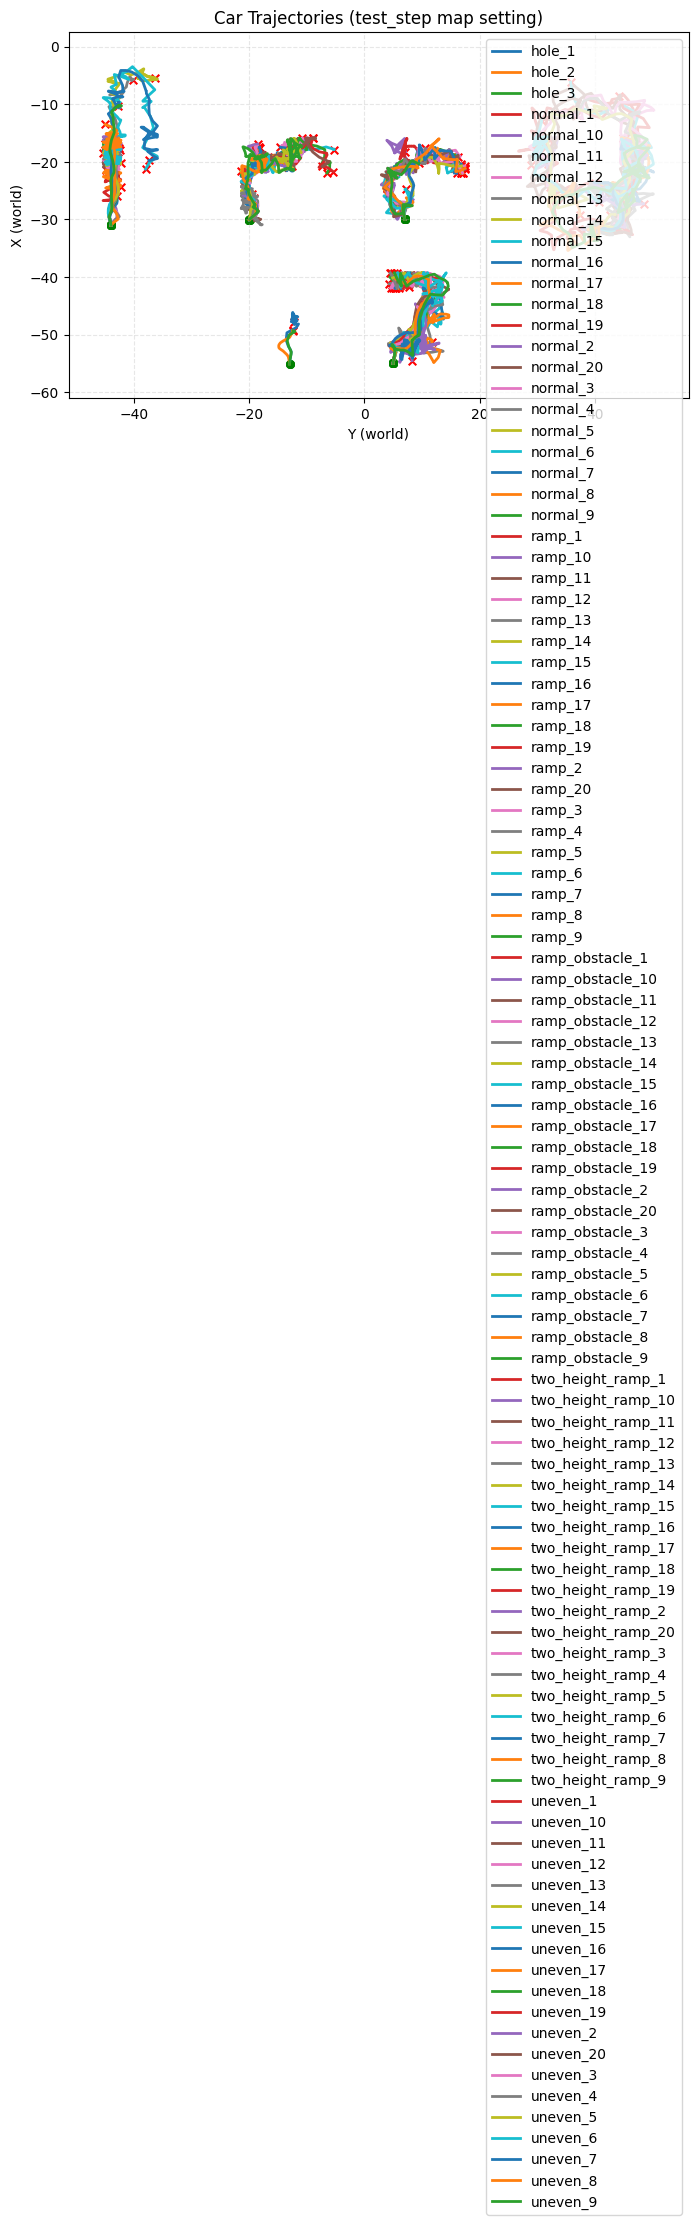

In [ ]:
# Simple trajectory plotter (no argparse)
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ========= user settings =========
# Working dir should be: PythonClient/car/trying/record
ROOT = 'step_6/'         # 'step' or 'randla'
SUBDIRS = None        # e.g., ['hole_1'] or None for all subfolders
MARGIN = 6.0          # same idea as STEP_config['grid_margin']
SAVE_PATH = 'videos/step/trajectories.png'  # or None to just show
SHOW = True
# =================================

def load_run_positions(run_dir):
    files = [f for f in os.listdir(run_dir) if f.lower().endswith('_car_state.json')]
    if not files:
        return np.empty((0, 2))
    files = sorted(files, key=lambda fn: int(os.path.splitext(fn)[0].split('_')[0]))
    xs, ys = [], []
    for f in files:
        fp = os.path.join(run_dir, f)
        try:
            with open(fp, 'r') as fh:
                data = json.load(fh)
            pos = data.get("kinematics_estimated", {}).get("position", {})
            xs.append(float(pos.get("x_val", np.nan)))
            ys.append(float(pos.get("y_val", np.nan)))
        except Exception:
            continue
    arr = np.array([xs, ys]).T
    return arr[~np.isnan(arr).any(axis=1)]

def compute_bounds(paths, margin):
    all_pts = np.vstack(paths)
    xmin, ymin = np.min(all_pts, axis=0)
    xmax, ymax = np.max(all_pts, axis=0)
    return (xmin - margin, xmax + margin, ymin - margin, ymax + margin)

root = os.path.abspath(ROOT)
if not os.path.isdir(root):
    raise FileNotFoundError(f'Root folder not found: {root}')

subdirs = SUBDIRS if SUBDIRS is not None else [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]

paths, names = [], []
for sub in subdirs:
    run_dir = os.path.join(root, sub)
    if not os.path.isdir(run_dir):
        continue
    traj = load_run_positions(run_dir)
    if traj.shape[0] >= 2:
        paths.append(traj)
        names.append(sub)

if not paths:
    print("No valid trajectories found.")
else:
    xmin, xmax, ymin, ymax = compute_bounds(paths, MARGIN)

    plt.figure(figsize=(8, 8))
    for traj, label in zip(paths, names):
        x = traj[:, 0]
        y = traj[:, 1]
        # Match test_step: plot Y on X-axis, X on Y-axis
        plt.plot(y, x, linewidth=2, label=label)
        plt.scatter(y[0], x[0], c='green', s=30)          # start
        plt.scatter(y[-1], x[-1], c='red', s=30, marker='x')  # end

    plt.xlim(ymin, ymax)
    plt.ylim(xmin, xmax)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xlabel('Y (world)')
    plt.ylabel('X (world)')
    plt.title('Car Trajectories (test_step map setting)')
    plt.legend()

    # if SAVE_PATH:
    #     os.makedirs(os.path.dirname(os.path.abspath(SAVE_PATH)), exist_ok=True)
    #     plt.savefig(SAVE_PATH, dpi=200, bbox_inches='tight')
    #     print(f"Saved figure to: {SAVE_PATH}")
    # if SHOW or not SAVE_PATH:
    plt.show()

In [ ]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt

# ===== settings =====
# Working dir should be PythonClient/car/trying/record
ROOT = 'randla'    # 'randla' or 'step'
MARGIN = 6.0       # like STEP_config['grid_margin']
SAVE_DIR = 'videos/randla/trajectories_per_env_grouped'
SHOW = True
# =====================

def extract_idx(fn):
    base = os.path.splitext(fn)[0]
    try:
        return int(base.split('_')[0])
    except:
        return 10**12

def load_run_positions(run_dir):
    files = [f for f in os.listdir(run_dir) if f.lower().endswith('_car_state.json')]
    if not files:
        return np.empty((0, 2))
    files = sorted(files, key=extract_idx)
    xs, ys = [], []
    for f in files:
        fp = os.path.join(run_dir, f)
        try:
            with open(fp, 'r') as fh:
                data = json.load(fh)
            pos = data.get("kinematics_estimated", {}).get("position", {})
            xs.append(float(pos.get("x_val", np.nan)))
            ys.append(float(pos.get("y_val", np.nan)))
        except Exception:
            continue
    arr = np.array([xs, ys]).T
    return arr[~np.isnan(arr).any(axis=1)]

def bounds_with_margin(trajs, margin):
    all_pts = np.vstack(trajs)
    xmin, ymin = np.min(all_pts, axis=0)
    xmax, ymax = np.max(all_pts, axis=0)
    return (xmin - margin, xmax + margin, ymin - margin, ymax + margin)

def base_env(name):
    # strip a single trailing _<digits>
    m = re.match(r'^(.*?)(?:_\d+)?$', name)
    return m.group(1) if m else name

root = os.path.abspath(ROOT)
if not os.path.isdir(root):
    raise FileNotFoundError(f'Root folder not found: {root}')

subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
# Group by base environment (e.g., hole_1, hole_2 -> hole)
groups = {}
for sub in subdirs:
    key = base_env(sub)
    groups.setdefault(key, []).append(sub)

os.makedirs(SAVE_DIR, exist_ok=True)

for env_name, runs in sorted(groups.items()):
    trajs, labels = [], []
    for run in sorted(runs):
        run_dir = os.path.join(root, run)
        traj = load_run_positions(run_dir)
        if traj.shape[0] >= 2:
            trajs.append(traj)
            labels.append(run)

    if not trajs:
        print(f"Skip (no data): {env_name}")
        continue

    xmin, xmax, ymin, ymax = bounds_with_margin(trajs, MARGIN)

    plt.figure(figsize=(7, 7))
    for traj, label in zip(trajs, labels):
        x = traj[:, 0]; y = traj[:, 1]
        # Match test_step: plot Y on X-axis, X on Y-axis
        plt.plot(y, x, linewidth=2, label=label)
        plt.scatter(y[0], x[0], c='green', s=25)
        plt.scatter(y[-1], x[-1], c='red', s=25, marker='x')

    plt.xlim(ymin, ymax)
    plt.ylim(xmin, xmax)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xlabel('Y (world)')
    plt.ylabel('X (world)')
    plt.title(f'Trajectories - {ROOT}/{env_name}')
    plt.legend(fontsize=8, loc='best')

    out_path = os.path.join(SAVE_DIR, f'{env_name}.png')
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f"Saved: {out_path}")
    if SHOW:
        plt.show()
    else:
        plt.close()

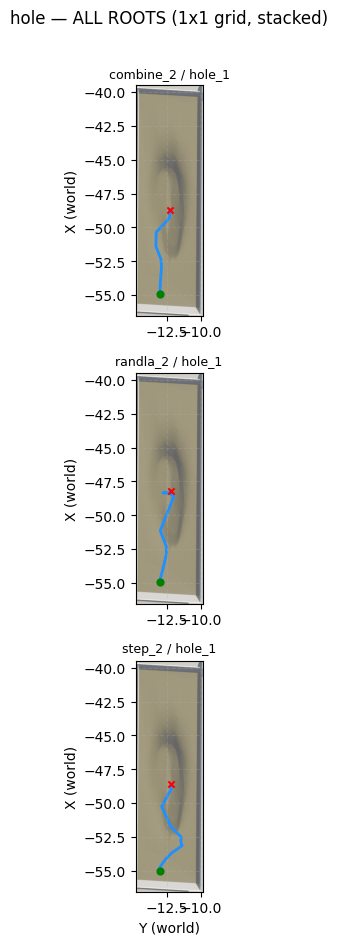

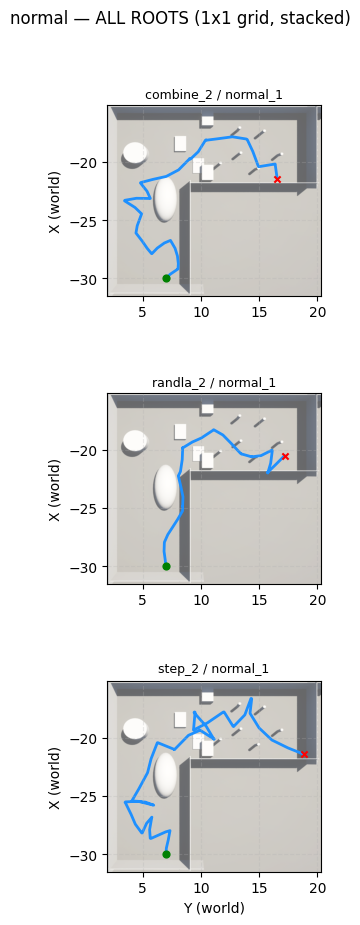

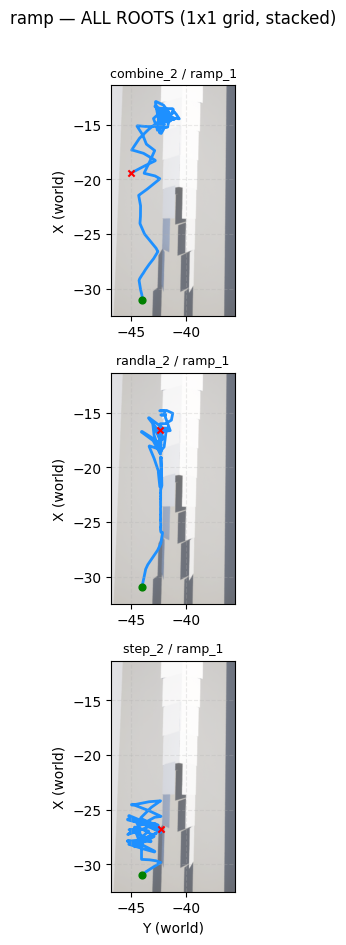

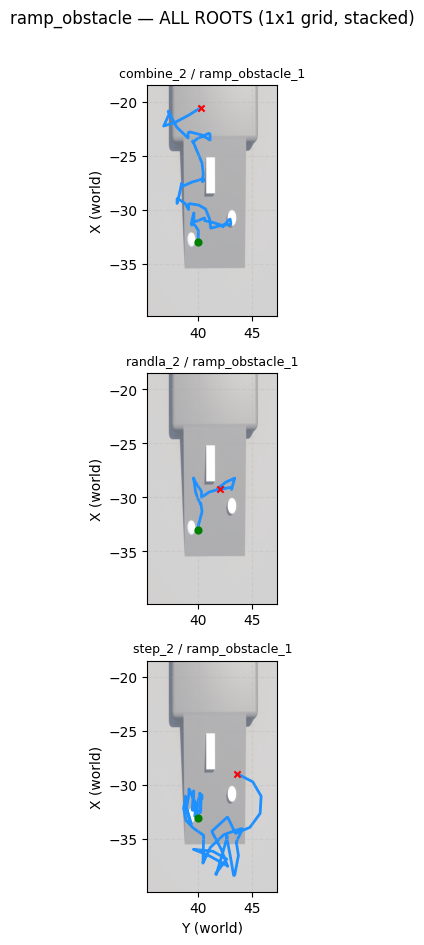

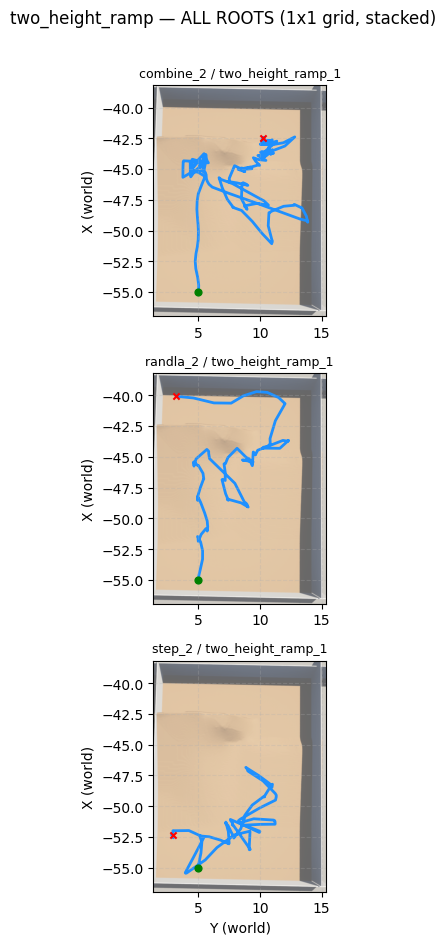

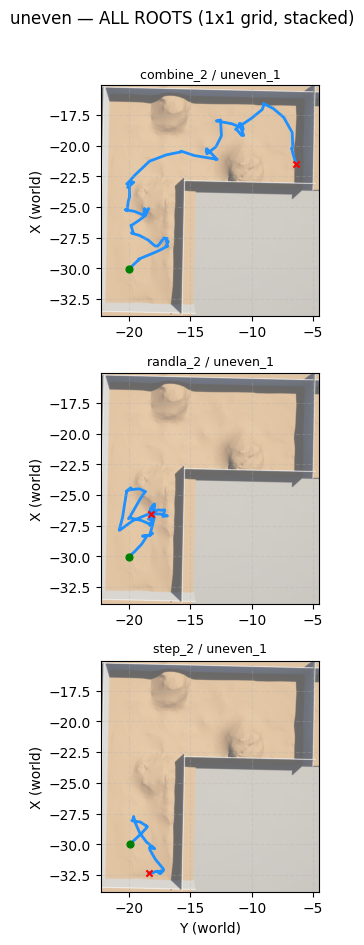

In [ ]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from math import ceil

# ===== settings =====
# Working dir should be PythonClient/car/trying/record
ROOTS = ['randla_2', 'step_2', 'combine_2']
MARGIN = 1.5      # like STEP_config['grid_margin']
SAVE_SUBDIR = 'trajectories_grid_1x5_stacked'   # goes under videos/COMBINED/
BG_DIR = 'image'   # background images folder (e.g., image/hole.png)
BG_ALPHA = 0.6     # transparency of background
FLIP_BG_HORIZ = True
SHOW = True
COLS = 1           # fixed columns in the grid
# =====================

def round_pair(p):
    try:
        return (int(round(float(p[0]))), int(round(float(p[1]))))
    except Exception:
        return None

def load_goal_map(stats_path):
    m = {}
    if not os.path.exists(stats_path):
        return m
    try:
        with open(stats_path, 'r') as fh:
            data = json.load(fh)
        for rec in data:
            sp = rec.get('start_point')
            gp = rec.get('goal_point')
            if isinstance(sp, (list, tuple)) and isinstance(gp, (list, tuple)) and len(sp) >= 2 and len(gp) >= 2:
                sp_key = round_pair(sp)
                gp_val = round_pair(gp)
                if sp_key and gp_val:
                    m[sp_key] = gp_val
    except Exception:
        pass
    return m

def extract_idx(fn):
    base = os.path.splitext(fn)[0]
    try:
        return int(base.split('_')[0])
    except:
        return 10**12

def load_run_positions(run_dir):
    files = [f for f in os.listdir(run_dir) if f.lower().endswith('_car_state.json')]
    if not files:
        return np.empty((0, 2))
    files = sorted(files, key=extract_idx)
    xs, ys = [], []
    for f in files:
        fp = os.path.join(run_dir, f)
        try:
            with open(fp, 'r') as fh:
                data = json.load(fh)
            pos = data.get("kinematics_estimated", {}).get("position", {})
            xs.append(float(pos.get("x_val", np.nan)))
            ys.append(float(pos.get("y_val", np.nan)))
        except Exception:
            continue
    arr = np.array([xs, ys]).T
    return arr[~np.isnan(arr).any(axis=1)]

def base_env(name):
    m = re.match(r'^(.*?)(?:_\d+)?$', name)
    return m.group(1) if m else name

def bounds_with_margin(trajs, margin):
    all_pts = np.vstack(trajs)
    xmin, ymin = np.min(all_pts, axis=0)
    xmax, ymax = np.max(all_pts, axis=0)
    return (xmin - margin, xmax + margin, ymin - margin, ymax + margin)

def load_bg_image(env_name):
    path = os.path.join(BG_DIR, f'{env_name}.png')
    if os.path.exists(path):
        try:
            return mpimg.imread(path)
        except Exception:
            return None
    return None

# ---------- PASS 1: collect data per env across all roots ----------
# env_runs[env] = list of tuples (root_name, run_label, traj_array)
env_runs = {}
# env_extra_points[env] = list of small arrays for start/goal points to stabilize bounds
env_extra_points = {}

for root_name in ROOTS:
    root = os.path.abspath(root_name)
    if not os.path.isdir(root):
        print(f'Root folder not found: {root}')
        continue

    # Per-root goal map (optional)
    stats_path = f'{root_name.split("_")[0]}_stats_1.json'
    GOAL_MAP = load_goal_map(stats_path) if os.path.exists(stats_path) else {}

    subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]

    # Group runs by environment base (e.g., hole_1, hole_2 -> hole)
    groups = {}
    for sub in subdirs:
        groups.setdefault(base_env(sub), []).append(sub)

    for env_name, runs in groups.items():
        for run in sorted(runs):
            run_dir = os.path.join(root, run)
            traj = load_run_positions(run_dir)
            if traj.shape[0] >= 2:
                env_runs.setdefault(env_name, []).append((root_name, run, traj))
                # add extra points for bounds from GOAL_MAP
                x0, y0 = float(traj[0, 0]), float(traj[0, 1])
                s_key = round_pair((x0, y0))
                if s_key in GOAL_MAP:
                    gx, gy = GOAL_MAP[s_key]
                    env_extra_points.setdefault(env_name, []).append(
                        np.array([[s_key[0], s_key[1]]], dtype=float))
                    env_extra_points[env_name].append(
                        np.array([[gx, gy]], dtype=float))

if not env_runs:
    print("No data found in any root; exiting.")
    raise SystemExit

# Compute global bounds per env (shared across all roots)
env_bounds = {}  # env -> (xmin, xmax, ymin, ymax)
for env_name, items in env_runs.items():
    pts = [traj for (_, _, traj) in items]
    pts.extend(env_extra_points.get(env_name, []))
    xmin, xmax, ymin, ymax = bounds_with_margin(pts, MARGIN)
    env_bounds[env_name] = (xmin, xmax, ymin, ymax)

# ---------- PASS 2: render one figure per env with all roots stacked ----------
combined_save_dir = os.path.join('videos', 'COMBINED', SAVE_SUBDIR)
os.makedirs(combined_save_dir, exist_ok=True)

for env_name in sorted(env_runs.keys()):
    items = env_runs[env_name]            # list of (root_name, run_label, traj)
    if not items:
        continue

    xmin, xmax, ymin, ymax = env_bounds[env_name]

    # Prepare background once per env
    raw_bg = load_bg_image(env_name)
    if raw_bg is not None:
        bg_for_axes = np.flipud(raw_bg) if FLIP_BG_HORIZ else raw_bg
        img = bg_for_axes.astype(np.float32)
        if img.max() > 1.0:
            img /= 255.0
        img = np.clip(img * 1.1, 0.0, 1.0)
    else:
        img = None

    # Build grid: all tiles from all roots for this env, ordered by root then run
    # Tile titles include the root to make grouping obvious
    items_sorted = sorted(items, key=lambda x: (x[0], x[1]))  # by root_name, then run_label
    n = len(items_sorted)
    cols = COLS
    rows = ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*3.2), squeeze=False)
    plt.subplots_adjust(wspace=0.12, hspace=0.12)

    for i, (root_name, run_label, traj) in enumerate(items_sorted):
        r, c = divmod(i, cols)
        ax = axes[r][c]

        # consistent bg image & extent per env
        if img is not None:
            ax.imshow(img, extent=[ymin, ymax, xmin, xmax], origin='lower',
                      alpha=BG_ALPHA, zorder=0)

        x = traj[:, 0]; y = traj[:, 1]
        ax.plot(y, x, linewidth=2, color='dodgerblue', zorder=1)

        # start/end markers (no cross-env GOAL_MAP here, since maps differ per root)
        ax.scatter(y[0], x[0], c='green', s=24, zorder=2)   # start
        ax.scatter(y[-1], x[-1], c='red', s=20, marker='x', zorder=2)  # end

        ax.set_xlim(ymin, ymax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, linestyle='--', alpha=0.25)
        ax.set_title(f'{root_name} / {run_label}', fontsize=9)

        # Label axes only on left/bottom
        if r == rows - 1:
            ax.set_xlabel('Y (world)')
        if c == 0:
            ax.set_ylabel('X (world)')

    # Hide unused axes
    for j in range(n, rows*cols):
        r, c = divmod(j, cols)
        axes[r][c].axis('off')

    fig.suptitle(f'{env_name} — ALL ROOTS (1x{COLS} grid, stacked)', fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    # out_path = os.path.join(combined_save_dir, f'{env_name}_stacked.png')
    # fig.savefig(out_path, dpi=200, bbox_inches='tight')
    # print(f"Saved: {out_path}")
    if SHOW:
        plt.show()
    else:
        plt.close(fig)


In [ ]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from math import ceil

# ===== settings =====
# Working dir should be PythonClient/car/trying/record
ROOTS = ['finalstep_1']
MARGIN = 1.5      # like STEP_config['grid_margin']
SAVE_SUBDIR = 'trajectories_grid_1x5'   # goes under videos/<root>/
BG_DIR = 'image'   # background images folder (e.g., image/hole.png)
BG_ALPHA = 0.6     # transparency of background
FLIP_BG_HORIZ = True
SHOW = True
COLS = 5          # keep columns fixed; rows will be derived from per-env max_n
# =====================

def round_pair(p):
    try:
        return (int(round(float(p[0]))), int(round(float(p[1]))))
    except Exception:
        return None

def load_goal_map(stats_path):
    print(f'Loading goal map from: {stats_path}')
    m = {}
    if not os.path.exists(stats_path):
        return m
    try:
        with open(stats_path, 'r') as fh:
            data = json.load(fh)
        for rec in data:
            sp = rec.get('start_point')
            gp = rec.get('goal_point')
    
            if isinstance(sp, (list, tuple)) and isinstance(gp, (list, tuple)) and len(sp) >= 2 and len(gp) >= 2:
                sp_key = round_pair(sp)
                gp_val = round_pair(gp)
                if sp_key and gp_val:
                    m[sp_key] = gp_val
    except Exception:
        pass
    return m

def extract_idx(fn):
    base = os.path.splitext(fn)[0]
    try:
        return int(base.split('_')[0])
    except:
        return 10**12

def load_run_positions(run_dir):
    files = [f for f in os.listdir(run_dir) if f.lower().endswith('_car_state.json')]
    if not files:
        return np.empty((0, 2))
    files = sorted(files, key=extract_idx)
    xs, ys = [], []
    for f in files:
        fp = os.path.join(run_dir, f)
        try:
            with open(fp, 'r') as fh:
                data = json.load(fh)
            pos = data.get("kinematics_estimated", {}).get("position", {})
            xs.append(float(pos.get("x_val", np.nan)))
            ys.append(float(pos.get("y_val", np.nan)))
        except Exception:
            continue
    arr = np.array([xs, ys]).T
    return arr[~np.isnan(arr).any(axis=1)]

def base_env(name):
    m = re.match(r'^(.*?)(?:_\d+)?$', name)
    return m.group(1) if m else name

def bounds_with_margin(trajs, margin):
    all_pts = np.vstack(trajs)
    xmin, ymin = np.min(all_pts, axis=0)
    xmax, ymax = np.max(all_pts, axis=0)
    return (xmin - margin, xmax + margin, ymin - margin, ymax + margin)

def load_bg_image(env_name):
    path = os.path.join(BG_DIR, f'{env_name}.png')
    if os.path.exists(path):
        try:
            return mpimg.imread(path)
        except Exception:
            return None
    return None

# ---------- PREPASS: build per-env metadata (max grid size + global bounds) ----------
env_meta = {}  # env_name -> {'max_n': int, 'bounds': (xmin,xmax,ymin,ymax)}

# Collect all trajectories + extra points per env to compute global bounds
env_points = {}  # env_name -> list of np arrays (N,2) to feed into bounds
for root_name in ROOTS:
    root = os.path.abspath(root_name)
    if not os.path.isdir(root):
        print(f'Root folder not found: {root}')
        continue

    # Per-root goal map (optional)
    stats_path = f'{root_name.split("_")[0]}_stats_4.json'
    GOAL_MAP = load_goal_map(stats_path) if os.path.exists(stats_path) else {}

    subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    groups = {}
    for sub in subdirs:
        groups.setdefault(base_env(sub), []).append(sub)

    # For each env under this root, load valid trajectories and update meta
    for env_name, runs in groups.items():
        # if env_name == "ramp":
        trajs_this_root_env = []
        valid_count = 0
        for run in sorted(runs):
            run_dir = os.path.join(root, run)
            traj = load_run_positions(run_dir)
            if traj.shape[0] >= 2:
                trajs_this_root_env.append(traj)
                valid_count += 1

                # extra points from GOAL_MAP for better bounds (start/goal)
                x0, y0 = float(traj[0, 0]), float(traj[0, 1])
                s_key = round_pair((x0, y0))
                if s_key in GOAL_MAP:
                    gx, gy = GOAL_MAP[s_key]
                    trajs_this_root_env.append(np.array([[s_key[0], s_key[1]]], dtype=float))
                    trajs_this_root_env.append(np.array([[gx, gy]], dtype=float))

        # Update per-env max grid size
        meta = env_meta.setdefault(env_name, {'max_n': 0, 'bounds': None})
        if valid_count > meta['max_n']:
            meta['max_n'] = valid_count

        # Stash points for global bounds
        if trajs_this_root_env:
            env_points.setdefault(env_name, []).extend(trajs_this_root_env)

# Compute global bounds per env (shared across all roots)
for env_name, pts in env_points.items():
    xmin, xmax, ymin, ymax = bounds_with_margin(pts, MARGIN)
    env_meta[env_name]['bounds'] = (xmin, xmax, ymin, ymax)

# ---------- PASS 2: render each root using per-env constants ----------
for root_name in ROOTS:
    root = os.path.abspath(root_name)
    if not os.path.isdir(root):
        print(f'Root folder not found: {root}')
        continue

    # Per-root goal map (optional)
    import glob, re

    def latest_stats(prefix):
        files = glob.glob(f'{prefix}_stats_*.json')
        if not files: return None
        def idx(f):
            m = re.search(r'_stats_(\d+)\.json$', f)
            return int(m.group(1)) if m else -1
        return max(files, key=idx)

    # in both passes:
    prefix = root_name.split("_")[0]
    stats_path = latest_stats(prefix)
    GOAL_MAP = load_goal_map(stats_path) if stats_path else {}
    print(GOAL_MAP)
    subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    groups = {}
    for sub in subdirs:
        groups.setdefault(base_env(sub), []).append(sub)

    save_dir = os.path.join('videos', root_name, SAVE_SUBDIR)
    os.makedirs(save_dir, exist_ok=True)

    for env_name, runs in sorted(groups.items()):
        # Skip envs that had no points anywhere (no bounds)
        meta = env_meta.get(env_name, None)
        if not meta or not meta['bounds']:
            print(f"Skip (no global bounds): {root_name} / {env_name}")
            continue

        xmin, xmax, ymin, ymax = meta['bounds']
        max_n = meta['max_n']
        if max_n <= 0:
            print(f"Skip (no data anywhere): {root_name} / {env_name}")
            continue

        # Fixed grid per env across all roots
        cols = COLS
        rows = ceil(max_n / cols)

        # Preload background image once per env with consistent processing
        raw_bg = load_bg_image(env_name)
        if raw_bg is not None:
            bg_for_axes = np.flipud(raw_bg) if FLIP_BG_HORIZ else raw_bg
            img = bg_for_axes.astype(np.float32)
            if img.max() > 1.0:
                img /= 255.0
            img = np.clip(img * 1.1, 0.0, 1.0)
        else:
            img = None

        # Gather current root's trajectories (actual n may be < max_n)
        trajs, labels = [], []
        for run in sorted(runs):
            run_dir = os.path.join(root, run)
            traj = load_run_positions(run_dir)
            if traj.shape[0] >= 2:
                trajs.append(traj); labels.append(run)

        if not trajs:
            print(f"Skip (no data in this root): {root_name} / {env_name}")
            continue

        # Build figure with *per-env* consistent layout
        fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*3.2), squeeze=False)
        plt.subplots_adjust(wspace=0.12, hspace=0.12)

        for i, (traj, label) in enumerate(zip(trajs, labels)):
            r, c = divmod(i, cols)
            ax = axes[r][c]

            # consistent bg image & extent across roots
            if img is not None:
                ax.imshow(img, extent=[ymin, ymax, xmin, xmax], origin='lower',
                          alpha=BG_ALPHA, zorder=0)

            x = traj[:, 0]; y = traj[:, 1]
            ax.plot(y, x, linewidth=2, color='dodgerblue', zorder=1)

            # start/goal markers (use GOAL_MAP if available)
            s_key = round_pair((x[0], y[0]))
 
            if s_key in GOAL_MAP:
                sx, sy = s_key
                gx, gy = GOAL_MAP[s_key]
                ax.scatter(sy, sx, c='green', s=24, zorder=2)            # start
                ax.scatter(gy, gx, c='black', s=40, marker='*', zorder=3)  # goal
            else:
                ax.scatter(y[0], x[0], c='green', s=24, zorder=2)

            ax.scatter(y[-1], x[-1], c='red', s=20, marker='x', zorder=2)  # end (orange/red)

            # Axes styling with global bounds
            ax.set_xlim(ymin, ymax)
            ax.set_ylim(xmin, xmax)
            ax.set_aspect('equal', adjustable='box')
            ax.grid(True, linestyle='--', alpha=0.25)
            ax.set_title(label, fontsize=9)
            # if r == rows - 1:
            #     ax.set_xlabel('Y (world)')
            # if c == 0:
            #     ax.set_ylabel('X (world)')

        # Hide any unused axes to preserve grid shape consistency
        n_actual = len(trajs)
        for j in range(n_actual, rows*cols):
            r, c = divmod(j, cols)
            axes[r][c].axis('off')

        fig.suptitle(f'{root_name} - {env_name} ', fontsize=12)
        fig.tight_layout(rect=[0, 0, 1, 0.97])

        out_path = os.path.join(save_dir, f'{env_name}_grid.png')
        fig.savefig(out_path, dpi=200, bbox_inches='tight')
        print(f"Saved: {out_path}")
        if SHOW:
            plt.show()
        else:
            plt.close(fig)


KeyboardInterrupt: 